In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [9]:
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(PARENT_DIR_PATH, "data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
CLIMATE_POLICY_DATA_DIR_PATH = os.path.join(RAW_DATA_DIR_PATH, "climate_policy_data")
DRIVERS_DATA_DIR_PATH = os.path.join(RAW_DATA_DIR_PATH, "governance_data")


In [10]:
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "historical_total_emission_per_country.csv"))
emissions_df.head()

,iso_alpha_3,year,total_emissions
0,ABW,1970,0.036970
1,ABW,1971,0.041825
2,ABW,1972,0.052708
3,ABW,1973,0.057704
4,ABW,1974,0.056999


## Class definition

In [11]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False


class FeaturePredictiveEvaluator:
    """
    Evaluate the predictive usefulness of a single feature for emissions models.
    """

    def __init__(
        self,
        df,
        target_col="total_emissions",
        country_col="iso_alpha_3",
        year_col="year",
        group_col="iso_alpha_3",
        include_year=True,
        log_target=True,
        n_splits=5,
        random_state=0,
    ):
        self.df = df.copy()
        self.target_col = target_col
        self.country_col = country_col
        self.year_col = year_col
        self.group_col = group_col
        self.log_target = log_target
        self.n_splits = n_splits
        self.random_state = random_state
        self.include_year = include_year

        self._prepare_target()
        self._prepare_baseline()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _prepare_target(self):
        y = self.df[self.target_col].values
        if self.log_target:
            y = np.log(y)
        self.y = y

    def _prepare_baseline(self):
        cols = [self.country_col]
        if self.include_year:
            cols.append(self.year_col)

        self.X_base = pd.get_dummies(
            self.df[cols],
            drop_first=True
        )

        self.groups = self.df[self.group_col]
        self.cv = GroupKFold(n_splits=self.n_splits)

    def _cv_rmse(self, X, model):
        rmses = []
        for train, test in self.cv.split(X, self.y, self.groups):
            model.fit(X.iloc[train], self.y[train])
            preds = model.predict(X.iloc[test])
            rmses.append(
                root_mean_squared_error(self.y[test], preds)
            )
        return float(np.mean(rmses))

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def within_group_std(self, feature):
        return (
            self.df
            .groupby(self.group_col)[feature]
            .std()
            .median()
        )

    def evaluate_feature(
        self,
        feature,
        ridge_alpha=1.0,
        test_xgboost=True,
        n_perm=20,
    ):
        """
        Run full predictive diagnostics for a single feature.
        """

        results = {}

        # 1. Variability check
        results["median_within_group_std"] = self.within_group_std(feature)

        # 2. Ridge regression RMSE
        ridge = Ridge(alpha=ridge_alpha)

        X_feat = pd.concat(
            [self.X_base, self.df[[feature]]],
            axis=1
        )

        results["rmse_base_ridge"] = self._cv_rmse(self.X_base, ridge)
        results["rmse_with_feature_ridge"] = self._cv_rmse(X_feat, ridge)
        results["rmse_delta_ridge"] = (
            results["rmse_with_feature_ridge"]
            - results["rmse_base_ridge"]
        )

        # 3. Permutation importance (trained on full sample)
        ridge.fit(X_feat, self.y)

        perm = permutation_importance(
            ridge,
            X_feat,
            self.y,
            n_repeats=n_perm,
            random_state=self.random_state,
        )

        results["permutation_importance"] = float(
            perm.importances_mean[X_feat.columns.get_loc(feature)]
        )

        # 4. Optional nonlinear test
        if test_xgboost and _HAS_XGB:
            xgb = XGBRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=self.random_state,
                n_jobs=-1,
            )

            results["rmse_base_xgb"] = self._cv_rmse(self.X_base, xgb)
            results["rmse_with_feature_xgb"] = self._cv_rmse(X_feat, xgb)
            results["rmse_delta_xgb"] = (
                results["rmse_with_feature_xgb"]
                - results["rmse_base_xgb"]
            )
        else:
            results["rmse_base_xgb"] = np.nan
            results["rmse_with_feature_xgb"] = np.nan
            results["rmse_delta_xgb"] = np.nan

        return pd.Series(results)


## Interaction Term Test

In [12]:
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_indices.csv"))
policy_df.head()

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock
0,AFG,1971,1,0.25,0.1875
1,AFG,1972,2,0.50,0.3750
2,AFG,1973,3,0.75,0.5625
3,AFG,1974,4,1.00,0.7500
4,AFG,1975,5,1.25,0.9375


In [13]:
interatcion_term_df = pd.read_excel(os.path.join(DRIVERS_DATA_DIR_PATH, "wgidataset_with_sourcedata-2025.xlsx"))
interatcion_term_df.head()

,ID variable (economy code/ gov. dimension/ year),Economy (name),Economy (code),Region,Income classification,Year,Governance dimension,Number of sources,Governance estimate (approx. -2.5 to +2.5),Standard error (estimate),...,OBI mean,PIA mean,PRS mean,RSF mean,VAB mean,VDM mean,WBS mean,WCY mean,WJP mean,WMO mean
0,ADOva1996,Andorra,ADO,NaN,NaN,1996,va,3,1.541954,0.301021,...,..,..,..,..,..,..,..,..,..,1
1,AFGva1996,Afghanistan,AFG,South Asia,Low income,1996,va,4,-2.235444,0.245080,...,..,..,..,..,..,0.246567,..,..,..,0.0625
2,AGOva1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,va,6,-1.746207,0.193985,...,..,..,0.25,..,..,0.320267,..,..,..,0.125
3,ALBva1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,va,5,-0.826077,0.221397,...,..,..,0.5,..,..,0.448356,..,..,..,0.25
4,AREva1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,va,6,-0.848031,0.193985,...,..,..,0.583333,..,..,0.332567,..,..,..,0.6875


In [14]:
fields_to_keep = [
    "Economy (code)",
    "Region",
    "Income classification",
    "Year",
    "Governance estimate (approx. -2.5 to +2.5)"
]

interaction_term_filtered = interatcion_term_df[fields_to_keep]
interaction_term_filtered.head()

,Economy (code),Region,Income classification,Year,Governance estimate (approx. -2.5 to +2.5)
0,ADO,NaN,NaN,1996,1.541954
1,AFG,South Asia,Low income,1996,-2.235444
2,AGO,Sub-Saharan Africa,Lower middle income,1996,-1.746207
3,ALB,Europe & Central Asia,Upper middle income,1996,-0.826077
4,ARE,Middle East & North Africa,High income,1996,-0.848031


In [15]:
# rename columns for merging
interaction_term_filtered = interaction_term_filtered.rename(
    columns={
        "Economy (code)": "iso_alpha_3",
        "Region": "region",
        "Income classification": "income_class",
        "Year": "year",
        "Governance estimate (approx. -2.5 to +2.5)": "governance_estimate"
    }
)


In [16]:
# Get min and max years
print("Interaction term data years:", interaction_term_filtered.year.min(), "-", interaction_term_filtered.year.max())

Interaction term data years: 1996 - 2024


In [17]:
# Do all countries have data for all years?
expected_years = set(range(1996, 2024))
countries_with_missing_years = {}
for country in interaction_term_filtered["iso_alpha_3"].unique():
    years = set(interaction_term_filtered[interaction_term_filtered["iso_alpha_3"] == country]["year"])
    missing_years = expected_years - years
    if missing_years:
        countries_with_missing_years[country] = missing_years

# countries_with_missing_years

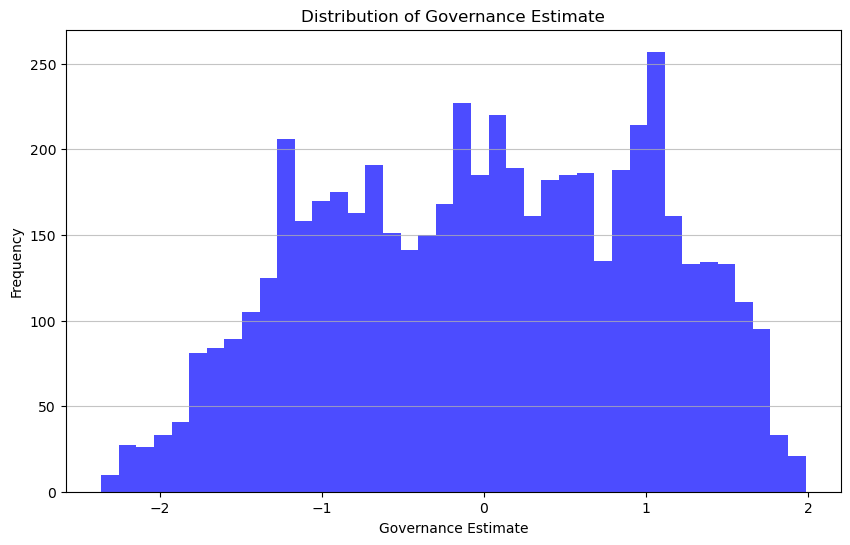

In [18]:
# Histogram of governance estimate
plt.figure(figsize=(10, 6))
plt.hist(interaction_term_filtered["governance_estimate"], bins=40, color='blue', alpha=0.7)
plt.title("Distribution of Governance Estimate")
plt.xlabel("Governance Estimate")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [19]:
# First we merge with interaction term data
merged_df = policy_df.merge(interaction_term_filtered, how="inner", on=["iso_alpha_3", "year"])

# Now we merge with emissions data
merged_df = merged_df.merge(emissions_df, how="inner", on=["iso_alpha_3", "year"])

merged_df

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,region,income_class,governance_estimate,total_emissions
0,AFG,1996,26,6.50,4.8750,South Asia,Low income,-2.235444,13.735236
1,AFG,1998,28,7.00,5.2500,South Asia,Low income,-2.357947,15.647833
2,AFG,2000,30,7.50,5.6250,South Asia,Low income,-2.297846,14.364940
3,AFG,2002,32,8.00,6.0000,South Asia,Low income,-1.364065,15.228572
4,AFG,2003,33,8.25,6.1875,South Asia,Low income,-1.267454,15.857565
...,...,...,...,...,...,...,...,...,...
4829,ZWE,2020,181,151.75,85.0625,Sub-Saharan Africa,Lower middle income,-1.169363,24.793786
4830,ZWE,2021,195,163.50,90.6875,Sub-Saharan Africa,Lower middle income,-1.176409,27.149709
4831,ZWE,2022,208,174.25,96.0625,Sub-Saharan Africa,Lower middle income,-1.192092,28.025627
4832,ZWE,2023,221,185.00,101.4375,Sub-Saharan Africa,Lower middle income,-1.202400,30.124985


In [20]:
merged_df.governance_estimate.describe()

count    4834.000000
mean       -0.070857
std         0.999071
min        -2.361104
25%        -0.887614
50%        -0.079963
75%         0.727513
max         1.984425
Name: governance_estimate, dtype: float64

In [21]:
# Standardize governance estimate
merged_df["gov_std"] = (
    merged_df["governance_estimate"]
    - merged_df["governance_estimate"].mean()
) / merged_df["governance_estimate"].std()

policy_vars = [
    "policy_flow_raw_stock",
    "policy_flow_jur_stock",
    "policy_flow_jur_nlp_stock",
]

for v in policy_vars:
    merged_df[f"{v}_x_gov"] = merged_df[v] * merged_df["gov_std"]

for v in policy_vars:
    merged_df[f"{v}_dm"] = (
        merged_df[v]
        - merged_df.groupby("iso_alpha_3")[v].transform("mean")
    )
    merged_df[f"{v}_dm_x_gov"] = merged_df[f"{v}_dm"] * merged_df["gov_std"]

merged_df.head()

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,region,income_class,governance_estimate,total_emissions,gov_std,policy_flow_raw_stock_x_gov,policy_flow_jur_stock_x_gov,policy_flow_jur_nlp_stock_x_gov,policy_flow_raw_stock_dm,policy_flow_raw_stock_dm_x_gov,policy_flow_jur_stock_dm,policy_flow_jur_stock_dm_x_gov,policy_flow_jur_nlp_stock_dm,policy_flow_jur_nlp_stock_dm_x_gov
0,AFG,1996,26,6.50,4.8750,South Asia,Low income,-2.235444,13.735236,-2.166601,-56.331620,-14.082905,-10.562179,-23.769231,51.498434,-6.230769,13.499590,-4.987981,10.806963
1,AFG,1998,28,7.00,5.2500,South Asia,Low income,-2.357947,15.647833,-2.289217,-64.098085,-16.024521,-12.018391,-21.769231,49.834500,-5.730769,13.118976,-4.612981,10.560116
2,AFG,2000,30,7.50,5.6250,South Asia,Low income,-2.297846,14.364940,-2.229061,-66.871837,-16.717959,-12.538469,-19.769231,44.066826,-5.230769,11.659705,-4.237981,9.446719
3,AFG,2002,32,8.00,6.0000,South Asia,Low income,-1.364065,15.228572,-1.294411,-41.421148,-10.355287,-7.766465,-17.769231,23.000686,-4.730769,6.123559,-3.862981,5.000284
4,AFG,2003,33,8.25,6.1875,South Asia,Low income,-1.267454,15.857565,-1.197710,-39.524434,-9.881109,-7.410831,-16.769231,20.084677,-4.480769,5.366663,-3.675481,4.402161


In [22]:
def plot_policy_time_series(country_iso3, df=merged_df, year_col="year",
                            value_col="policy_stringency_index", figsize=(10, 6),
                            marker='o', title=None, show=True):
    """
    Plot policy stringency index time series for a given ISO3 country code.
    Returns (fig, ax) if data exists, otherwise returns None.
    """
    data = df[df["iso_alpha_3"] == country_iso3].sort_values(year_col)
    if data.empty:
        print(f"No data for {country_iso3}")
        return None

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(data[year_col], data[value_col], marker=marker)
    ax.set_title(title or f"Policy Stringency Index Over Time for {country_iso3}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Policy Stringency Index")
    ax.grid()
    if show:
        plt.show()
    return fig, ax

# Example usage:
# plot_policy_time_series("USA")

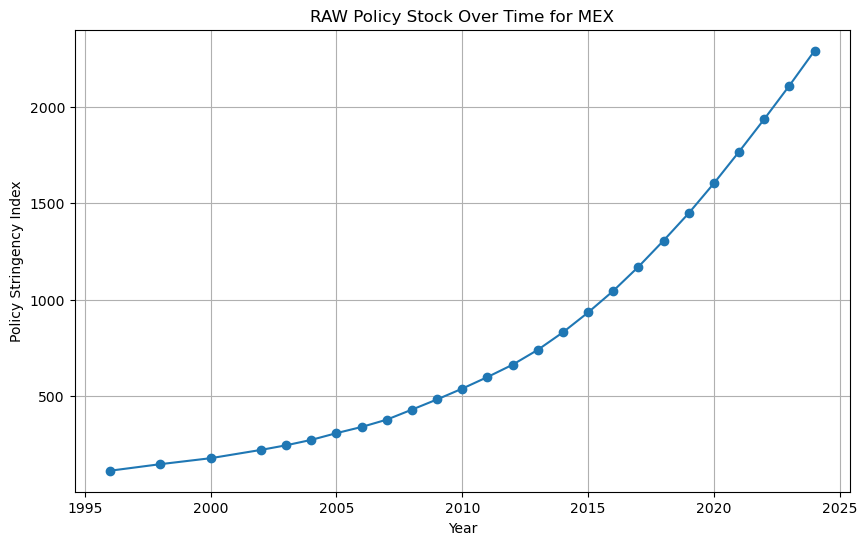

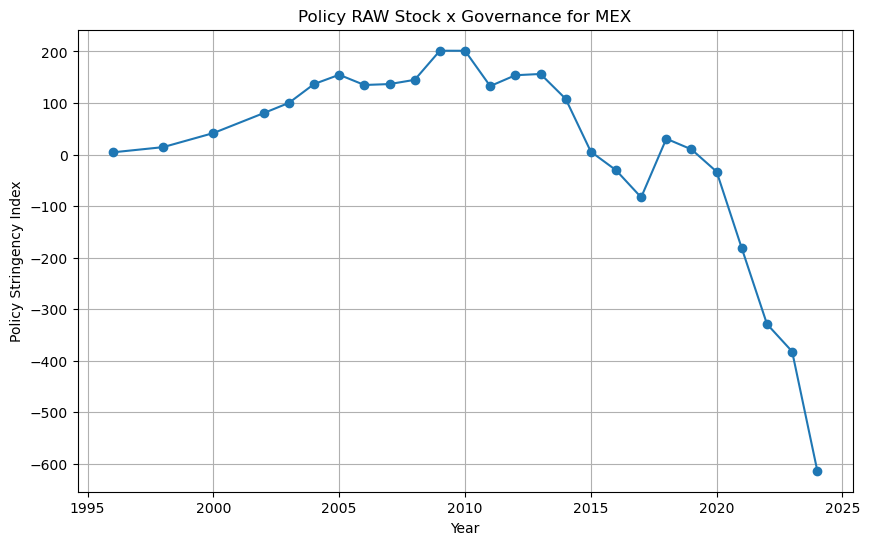

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Policy RAW Stock x Governance for MEX'}, xlabel='Year', ylabel='Policy Stringency Index'>)

In [25]:
plot_policy_time_series("MEX", value_col="policy_flow_raw_stock", title="RAW Policy Stock Over Time for MEX")
plot_policy_time_series("MEX", value_col="policy_flow_raw_stock_x_gov", title="Policy RAW Stock x Governance for MEX")
# plot_policy_time_series("MEX", value_col="policy_flow_raw_stock_dm_x_gov")

In [15]:
evaluator = FeaturePredictiveEvaluator(merged_df, include_year=False)
for v in policy_vars:
    print(v)
    print(evaluator.evaluate_feature(v))


policy_flow_raw_stock


median_within_group_std    67.096627
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.460230
rmse_delta_ridge           -0.046747
permutation_importance      0.003975
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.136379
rmse_delta_xgb             -0.374307
dtype: float64
policy_flow_jur_stock
median_within_group_std    50.908144
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.459698
rmse_delta_ridge           -0.047280
permutation_importance      0.004001
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.093363
rmse_delta_xgb             -0.417324
dtype: float64
policy_flow_jur_nlp_stock
median_within_group_std    28.336307
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.453965
rmse_delta_ridge           -0.053012
permutation_importance      0.004750
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.101806
rmse_delta_xgb             -0.408880
dtype: float64


In [16]:
for v in policy_vars:
    print(f"{v}_x_gov")
    print(evaluator.evaluate_feature(f"{v}_x_gov"))

policy_flow_raw_stock_x_gov
median_within_group_std    45.538148
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.509124
rmse_delta_ridge            0.002147
permutation_importance      0.000011
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.137049
rmse_delta_xgb             -0.373638
dtype: float64
policy_flow_jur_stock_x_gov
median_within_group_std    3.297268e+01
rmse_base_ridge            2.506977e+00
rmse_with_feature_ridge    2.508103e+00
rmse_delta_ridge           1.126124e-03
permutation_importance     9.486539e-07
rmse_base_xgb              2.510687e+00
rmse_with_feature_xgb      2.073842e+00
rmse_delta_xgb            -4.368444e-01
dtype: float64
policy_flow_jur_nlp_stock_x_gov
median_within_group_std    18.409686
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.509489
rmse_delta_ridge            0.002512
permutation_importance      0.000022
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.087310
rmse_de

In [17]:
for v in policy_vars:
    print(f"{v}_dm_x_gov")
    print(evaluator.evaluate_feature(f"{v}_dm_x_gov"))

policy_flow_raw_stock_dm_x_gov
median_within_group_std    39.443199
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.505740
rmse_delta_ridge           -0.001237
permutation_importance      0.000534
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.194304
rmse_delta_xgb             -0.316383
dtype: float64
policy_flow_jur_stock_dm_x_gov
median_within_group_std    28.537148
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.505791
rmse_delta_ridge           -0.001186
permutation_importance      0.000523
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.174586
rmse_delta_xgb             -0.336100
dtype: float64
policy_flow_jur_nlp_stock_dm_x_gov
median_within_group_std    18.788494
rmse_base_ridge             2.506977
rmse_with_feature_ridge     2.505740
rmse_delta_ridge           -0.001237
permutation_importance      0.000577
rmse_base_xgb               2.510687
rmse_with_feature_xgb       2.186763
rmse_delta_xgb        

In [30]:
merged_df_to_save = merged_df[["iso_alpha_3", "year", "policy_flow_jur_stock_x_gov"]]
merged_df_to_save.head()

,iso_alpha_3,year,policy_flow_jur_stock_x_gov
0,AFG,1996,-14.082905
1,AFG,1998,-16.024521
2,AFG,2000,-16.717959
3,AFG,2002,-10.355287
4,AFG,2003,-9.881109


In [31]:
merged_df_to_save.to_csv(
    os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_count_x_gov.csv"),
    index=False
)